# Exploring Word Embeddings with Word2Vec

## Introduction

Word embeddings, which are dense vector representations of words, have revolutionized the way we handle textual data in machine learning. Among the various methods to obtain word embeddings, Google's Word2Vec has stood out due to its ability to capture semantic relationships between words. In this notebook, we'll delve into the Word2Vec embeddings and visualize them to understand their structure better.

### Objectives:

1. **Load a Pretrained Word2Vec Model**: We'll use the `gensim` library to load Google's pretrained Word2Vec model. This model has been trained on a massive amount of data and can capture intricate semantic relationships.

2. **Explore the Capabilities of Word2Vec**: We'll showcase some fundamental operations that can be performed using Word2Vec, such as:
    - Finding words most similar to a given word.
    - Computing the similarity score between two words.
    - Solving analogies. For instance, given "man is to king as woman is to ?", the model can predict the word that best completes the analogy.

3. **Visualize Word Embeddings**: The embeddings are typically in a high-dimensional space (e.g., 300 dimensions). We'll use dimensionality reduction techniques, like PCA, to visualize these embeddings in a 2D space. This visualization will help us understand how similar words cluster together.

## Let's Dive In!

With the background set, let's dive into the exploration and see the magic of Word2Vec in action!


The gensim.downloader utility provides a convenient way to download several pre-trained models:

In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 13.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatib

In [ ]:
import gensim.downloader as api
path = api.load("word2vec-google-news-300", return_path=True)
print(path)

[==================================================] 100.0% 1662.8/1662.8MB downloaded
/root/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz


## Load the Pretrained Word2Vec Model

Once you've downloaded the model, you can load it into memory:

In [ ]:
from gensim.models import KeyedVectors

model = KeyedVectors.load_word2vec_format(path, binary=True)


## Test the model

Try different words as input for your model. What is the size of the word embeddings?

In [ ]:
len(model['word'])

300

In [ ]:
model['word']

array([ 3.59375000e-01,  4.15039062e-02,  9.03320312e-02,  5.46875000e-02,
       -1.47460938e-01,  4.76074219e-02, -8.49609375e-02, -2.04101562e-01,
        3.10546875e-01, -1.05590820e-02, -6.15234375e-02, -1.55273438e-01,
       -1.52343750e-01,  8.54492188e-02, -2.70996094e-02,  3.84765625e-01,
        4.78515625e-02,  2.58789062e-02,  4.49218750e-02, -2.79296875e-01,
        9.09423828e-03,  4.08203125e-01,  2.40234375e-01, -3.06640625e-01,
       -1.80664062e-01,  4.73632812e-02, -2.63671875e-01,  9.08203125e-02,
        1.37695312e-01, -7.20977783e-04,  2.67333984e-02,  1.92382812e-01,
       -2.29492188e-02,  9.70458984e-03, -7.37304688e-02,  4.29687500e-01,
       -7.93457031e-03,  1.06445312e-01,  2.80761719e-02, -2.29492188e-01,
       -1.91650391e-02, -2.36816406e-02,  3.51562500e-02,  1.71875000e-01,
       -1.12304688e-01,  6.25000000e-02, -1.69921875e-01,  1.29882812e-01,
       -1.54296875e-01,  1.58203125e-01, -7.76367188e-02,  1.78710938e-01,
       -1.72851562e-01,  

Here are a few things the model can do:
- Find Most Similar Words:

In [ ]:
similar_words = model.most_similar('cat', topn=5)
print(similar_words)


[('cats', 0.8099379539489746), ('dog', 0.760945737361908), ('kitten', 0.7464985251426697), ('feline', 0.7326234579086304), ('beagle', 0.7150582671165466)]


- Compute Similarity between Two Words:

In [ ]:
similarity = model.similarity('king', 'queen')
print(similarity)

similarity = model.similarity('king', 'lunch')
print(similarity)


0.6510956
0.07222404


- Use the Analogy Feature:

Given the analogy "man is to king as woman is to ?", the model can find the word that best completes the analogy:

In [ ]:
analogy_result = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)
print(analogy_result)


[('queen', 0.7118193507194519)]


## Plotting Word Embeddings

To visualize word embeddings, we need to reduce their dimensionality to 2D. Let's pick a few words and use PCA to reduce their dimensions. Then, we'll plot them:

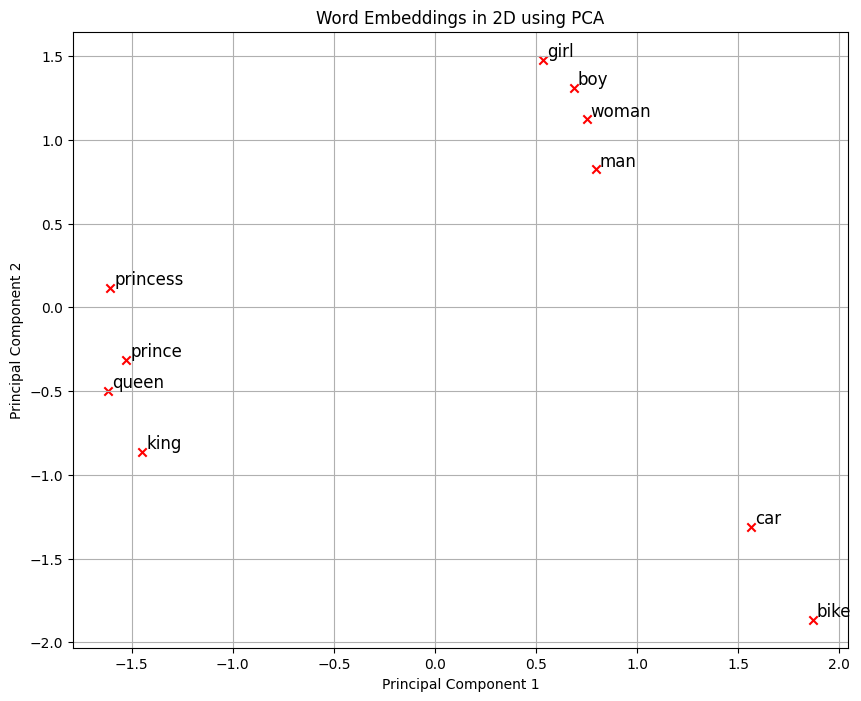

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Choose words to visualize
words = ['king', 'queen', 'man', 'woman', 'prince', 'princess', 'boy', 'girl', 'car', 'bike']

# Extract embeddings for these words
embeddings = [model[word] for word in words]

# Use PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Plot the results
plt.figure(figsize=(10, 8))
for i, word in enumerate(words):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], marker='x', color='red')
    plt.text(embeddings_2d[i, 0]+0.02, embeddings_2d[i, 1]+0.02, word, fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Word Embeddings in 2D using PCA')
plt.grid(True)
plt.show()


Downlaoad a dataset for translation

# Machine Translation with Huggingface

## Introduction

Machine translation the task of converting text from one language to another. In this notebook, we will leverage pre-trained models and datasets from Hugging Face, a platform offering a vast array of NLP resources.

We will go through the following:

### 1. Loading a Translation Dataset from Hugging Face:
Hugging Face's `datasets` library offers a plethora of datasets catering to numerous NLP tasks. We will fetch a translation dataset, which will serve as our ground truth for evaluating translation performance.

### 2. Acquiring a Pretrained Translation Model and Tokenizer:
The power of neural machine translation often lies in models trained on vast amounts of data. Thankfully, Hugging Face's `transformers` library provides access to several state-of-the-art pre-trained models. We will retrieve a model specifically trained for our language pair of interest, along with its tokenizer, facilitating the conversion of text into a format the model can understand.

### 3. Evaluating Machine Translation:
Once armed with our model, we will put it to the test! After translating an example our dataset's source sentences, we will evaluate the quality of these translations compared to the reference translations. For this, we'll use the BLEU (Bilingual Evaluation Understudy) score, a widely-accepted metric in the NLP community for assessing translation quality.


Let's first install a few useful libraries.

In [ ]:
!pip install datasets
!pip install transformers
!pip install sentencepiece

Import the dataset from Hugging Face

In [ ]:
from datasets import load_dataset

dataset = load_dataset('wmt16', 'de-en')

# find the dataset at: https://huggingface.co/datasets/wmt/wmt16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

de-en/train-00000-of-00003.parquet:   0%|          | 0.00/282M [00:00<?, ?B/s]

de-en/train-00001-of-00003.parquet:   0%|          | 0.00/267M [00:00<?, ?B/s]

de-en/train-00002-of-00003.parquet:   0%|          | 0.00/277M [00:00<?, ?B/s]

de-en/validation-00000-of-00001.parquet:   0%|          | 0.00/343k [00:00<?, ?B/s]

de-en/test-00000-of-00001.parquet:   0%|          | 0.00/475k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4548885 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2999 [00:00<?, ? examples/s]

In [ ]:
# Checking the dataset structure
print(dataset)

# Viewing an example from the training set
print(dataset['train'][0])


DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 4548885
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2169
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2999
    })
})
{'translation': {'de': 'Wiederaufnahme der Sitzungsperiode', 'en': 'Resumption of the session'}}


Let's pick a sentence from the testing dataset

In [ ]:
test_split = dataset['test']
line = test_split['translation'][1]
line

{'de': 'Das Verhältnis zwischen Obama und Netanyahu ist nicht gerade freundschaftlich.',
 'en': 'The relationship between Obama and Netanyahu is not exactly friendly.'}

## Loading a Pretrained MarianMT Model for English-to-German Translation

In the provided code snippet, we're leveraging the `transformers` library from Hugging Face to load a specific machine translation model and its associated tokenizer:

1. **Import Necessary Modules**:
   We start by importing the relevant classes:
   - `MarianMTModel`: Represents the actual translation model that can convert sequences from one language to another.
   - `MarianTokenizer`: Aids in converting text into a format (tokens) that the model can understand and vice-versa.

2. **Specify the Model Name**:
   We define the `model_name` as `"Helsinki-NLP/opus-mt-en-de"`. This points to a pretrained model on the Hugging Face Model Hub that's optimized for English-to-German translations. The naming convention typically follows the pattern `<organization>/<model-name>`, indicating the group or individual that trained the model and the specific model identifier.

3. **Load the Model and Tokenizer**:
   Using the `from_pretrained` method, we:
   - Load the translation model (`AutoModelForSeq2SeqLM`) using the specified `model_name`.
   - Load the associated tokenizer (`AutoTokenizer`) that knows how to tokenize English text for this specific model and convert German tokens back into text.

With these steps, we're fully equipped to process English text, feed it into our translation model, and obtain German translations.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "Helsinki-NLP/opus-mt-en-de"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [ ]:
model

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(58101, 512, padding_idx=58100)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(58101, 512, padding_idx=58100)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [ ]:
tokenizer.tokenize(line['de'])

['▁Das',
 '▁Ver',
 'hä',
 'lt',
 'nis',
 '▁z',
 'w',
 'ischen',
 '▁Obama',
 '▁und',
 '▁Net',
 'anya',
 'hu',
 '▁is',
 't',
 '▁nicht',
 '▁g',
 'er',
 'ade',
 '▁f',
 're',
 'und',
 'schaft',
 'lich',
 '.']

In [ ]:
def translate(text, model, tokenizer):
    # Tokenize the source text
    inputs = tokenizer.encode(text, return_tensors="pt", truncation=True, padding="max_length", max_length=512)

    # Perform the translation
    outputs = model.generate(inputs, max_length=512, num_beams=4, early_stopping=True)
    translated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return translated_text

# Test the function
source_text = line['en']
translated = translate(source_text, model, tokenizer)
print(translated)


Die Beziehung zwischen Obama und Netanjahu ist nicht gerade freundlich.


In [ ]:
source_text

'The relationship between Obama and Netanyahu is not exactly friendly.'

## Evaluating translation with the BLEU Score

BLEU (Bilingual Evaluation Understudy) is a metric used to evaluate the quality of machine-generated translations in relation to human-provided reference translations. Introduced in a [paper](https://www.aclweb.org/anthology/P02-1040.pdf) by Kishore Papineni and others in 2002, BLEU has since become one of the most widely-used metrics in machine translation evaluation.

### Key Concepts:

 **Precision of N-grams**:
   - At its core, BLEU considers the precision of n-grams (contiguous sequences of n items from a text) in the machine-generated translation with respect to the reference translation.
   - The precision is computed for different n-gram lengths, such as unigrams (1-grams), bigrams (2-grams), trigrams (3-grams), and so on.


### Interpreting the Score:

- The BLEU score ranges from 0 to 1 (or 0% to 100% when multiplied by 100).
- A score of 1 indicates that the machine translation matches the human reference translation perfectly.
- Different human translators can produce slightly different translations for the same source text.

### Limitations:

- It may not always correlate perfectly with human judgment, especially for individual sentences.
- BLEU assumes that more matches with the reference translation indicate better quality.


In [ ]:
# If `new_translation` is a single string, you can tokenize it as:
new_translation_tokens = translated.split()

# Similarly, for reference_texts:
reference_texts_tokens = [line['de'].split()]


In [ ]:
new_translation_tokens

['Die',
 'Beziehung',
 'zwischen',
 'Obama',
 'und',
 'Netanjahu',
 'ist',
 'nicht',
 'gerade',
 'freundlich.']

In [ ]:
reference_texts_tokens

[['Das',
  'Verhältnis',
  'zwischen',
  'Obama',
  'und',
  'Netanyahu',
  'ist',
  'nicht',
  'gerade',
  'freundschaftlich.']]

Import the sentence_bleu score from the nltk library

In [ ]:
from nltk.translate.bleu_score import sentence_bleu
import nltk

In [ ]:
smooth = nltk.translate.bleu_score.SmoothingFunction().method2

sentence_bleu(reference_texts_tokens, new_translation_tokens, smoothing_function = smooth)

0.33437015248821106

What if you have no time to waste?

## Hugging Face Pipelines: Simplifying NLP Tasks

Hugging Face's `transformers` library offers a high-level utility called `pipelines` that provides an easy-to-use interface for several common natural language processing (NLP) tasks. Built on top of the vast collection of pretrained models available in the library, the `pipelines` utility abstracts away many of the underlying complexities, making it straightforward for both newcomers and experienced practitioners to leverage state-of-the-art NLP models.

### Key Features:

1. **Predefined Tasks**:
   - `pipelines` supports a variety of tasks out-of-the-box, including text classification, token classification, question answering, text generation, and more.

2. **Minimal Code**:
   - With just a few lines of code, users can obtain meaningful results without needing to worry about tokenization, model inference, or post-processing.

3. **Flexibility**:
   - While `pipelines` offers simplicity, it doesn't sacrifice flexibility. Users can easily customize the underlying models, tokenizers, and more.

4. **Broad Model Support**:
   - Whether you're looking to use BERT for token classification, GPT-2 for text generation, or any other model in the Hugging Face Model Hub, there's likely a pipeline ready for it.


The `pipelines` utility in the Hugging Face `transformers` library is a powerful tool that democratizes access to state-of-the-art NLP models. Whether you're building an AI-powered chatbot, a document summarization system, or just exploring the capabilities of modern NLP, `pipelines` can accelerate your implementations.



In [ ]:
from transformers import pipeline

# Initialize the translation pipeline
translator = pipeline("translation_en_to_de", model="Helsinki-NLP/opus-mt-en-de", tokenizer="Helsinki-NLP/opus-mt-en-de")

# Translate a sentence
source_text = "Hello, how are you?"
translation = translator(source_text)

print(translation[0]['translation_text'])


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda:0


Hallo, wie geht's?


In [ ]:
translator = pipeline("translation_en_to_da", model="Helsinki-NLP/opus-mt-en-da", tokenizer="Helsinki-NLP/opus-mt-en-da")
# Translate a sentence
source_text = "Hello, how are you?"
translation = translator(source_text)

print(translation[0]['translation_text'])

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/300M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/300M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/788k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/820k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Hej, hvordan går det?


Want to Translate to Faroese? Use our models!

In [ ]:
from transformers import pipeline

model_name = "barbaroo/nllb_200_1.3B_en_fo"

translator = pipeline(
    "translation",
    model=model_name,
    tokenizer=model_name,
    src_lang="eng_Latn",   # Language code for English
    tgt_lang="fao_Latn"    # Language code for Faroese
)

text = "Hello, how are you?"
translation = translator(text)
print(translation)


config.json:   0%|          | 0.00/858 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/483M [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


[{'translation_text': 'Hey, hvussu gongur?'}]


Pipelines are available for many different tasks!

## Available Tasks in Hugging Face's `pipeline` Utility

Hugging Face's `pipeline` utility in the `transformers` library provides a high-level, easy-to-use API for various NLP tasks. As of January 2022, the following tasks are supported:

- **Feature Extraction**:
  - `feature-extraction`
  
- **Text Classification**:
  - `text-classification`
  
- **Sentiment Analysis**:
  - `sentiment-analysis` (alias for `text-classification`)
  
- **Token Classification**:
  - `token-classification`
  
- **Named Entity Recognition (NER)**:
  - `ner` (alias for `token-classification`)
  
- **Question Answering**:
  - `question-answering`
  
- **Masked Language Modeling**:
  - `fill-mask`
  
- **Summarization**:
  - `summarization`
  
- **Translation**:
  - `translation_xx_to_yy` (where `xx` and `yy` are source and target language codes, respectively)
  
- **Text-to-Text Generation**:
  - `text2text-generation`
  
- **Text Generation**:
  - `text-generation`
  
- **Zero-Shot Classification**:
  - `zero-shot-classification`
  
- **Conversational Models**:
  - `conversational`
  
For translation tasks, the format `translation_xx_to_yy` allows flexibility in specifying any source (`xx`) and target (`yy`) language combination, provided there's a model that supports that particular pair.

To always get the most up-to-date list of supported tasks, refer to the official Hugging Face documentation or inspect the source code of the `pipeline` function in the `transformers` library.


Let's try some of these pipelines!

In [ ]:
from transformers import pipeline

# Initialize the sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis")

# Analyze the sentiment of a sample sentence
result = sentiment_analyzer("I love Artificial Intelligence !!")

result

In [ ]:
# Initialize the text generation pipeline
text_generator = pipeline("text-generation")

# Generate text based on a given prompt
prompt = "Once upon a time"
generated_text = text_generator(prompt, max_length=100, do_sample=True, temperature=0.7)

print('\n')
print(generated_text[0]['generated_text'])


In [ ]:
# Initialize the question answering pipeline
qa_pipeline = pipeline("question-answering")

# Define the context and the question
context = """
The Transformers library provides state-of-the-art machine learning architectures like BERT, GPT-2, and RoBERTa.
It is designed by Hugging Face for natural language processing tasks such as text classification, extraction, and translation.
"""
question = "Who designed the Transformers library?"

# Extract the answer from the context
answer = qa_pipeline(question=question, context=context)

print(f"Question: {question}")
print(f"Answer: {answer['answer']} (with score: {answer['score']:.4f})")


In [ ]:
from transformers import pipeline

# Initialize the NER pipeline
ner_pipeline = pipeline("ner")

# Define the text
text = "Hugging Face is a company based in New York City. Its Transformers library is very popular in the NLP community."

# Recognize named entities in the text
entities = ner_pipeline(text)

# Display the recognized entities
for entity in entities:
    word = entity["word"]
    label = entity["entity"]
    score = entity["score"]
    print(f"Entity: {word}, Label: {label}, Score: {score:.4f}")


No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Entity: Hu, Label: I-ORG, Score: 0.9924
Entity: ##gging, Label: I-ORG, Score: 0.9350
Entity: Face, Label: I-ORG, Score: 0.9612
Entity: New, Label: I-LOC, Score: 0.9993
Entity: York, Label: I-LOC, Score: 0.9991
Entity: City, Label: I-LOC, Score: 0.9992
Entity: Transformers, Label: I-ORG, Score: 0.9495
Entity: NL, Label: I-ORG, Score: 0.7389
Entity: ##P, Label: I-ORG, Score: 0.5698


# Open source LLMs

Example with Llama 3

In [ ]:
! pip install transformers accelerate bitsandbytes


Modern chat approach (above): works with most instruction/chat-tuned causal LMs that provide a tokenizer and a chat template on the Hub. Examples you can use like this:

- Llama (e.g., Meta-Llama-3-8B/70B Instruct)

- Mistral / Mixtral Instruct

- Qwen/Qwen2 Instruct

- Phi-3 (mini/medium) Instruct

- Gemma Instruct, etc.

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_id = "meta-llama/Meta-Llama-3-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,               # quantize weights to 4 bits
    bnb_4bit_use_double_quant=True,  # second quantization layer for better accuracy
    bnb_4bit_quant_type="nf4",       # NormalFloat4, best tradeoff
    bnb_4bit_compute_dtype=torch.bfloat16,  # compute in bf16 (safer than fp16)
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",  # automatically put layers on available GPUs
)

# Example chat message
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Hi there! Can you help me plan a weekend hike?"},
]

inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt").to(model.device)

outputs = model.generate(
    inputs,
    max_new_tokens=256,
    temperature=0.7,
    top_p=0.9,
    do_sample=True,
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


system

You are a helpful assistant.user

Hi there! Can you help me plan a weekend hike?assistant

I'd be happy to help you plan a weekend hike. Before we get started, can you please provide me with some details?

* What's your preferred location for the hike? Are you looking for something close to home or willing to travel a bit?
* What's your hiking experience level? Are you a beginner, intermediate, or advanced hiker?
* How many miles are you looking to hike? Are you looking for a short, easy day hike or a longer, more challenging multi-day backpacking trip?
* Are there any specific features you're looking for in your hike, such as scenic views, waterfalls, or historic landmarks?
* Do you have a preferred type of terrain, such as forests, mountains, or coastal trails?
* Are you planning to camp overnight or just do a day hike?
* Do you have any specific dates or time frame in mind for your hike?

Once I have this information, I can start providing you with some personalized recommen

Now you are ready to bring NLP into your applications!!